In [6]:
import sys
sys.path.insert(0, '../')
from seeker_utils import get_license_path
import seeker as skr
lic_path = get_license_path()
#print(lic_path)

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
# https://www.youtube.com/watch?v=NggRnif1Kds


Evaluating deterministically...
Mode: deterministic
  Solution: [6000.0, 10500.0]
  Expected Profit: 3769.02
  VaR 5%: -4753.54
  CVaR 5%: -7588.93

Optimizing expected profit...
At time 3.912175: Objective = 5548.858929; Status = Feasible; Evaluations = 6823
At time 7.673323: Objective = 5550.390786; Status = Feasible; Evaluations = 13305
At time 11.425223: Objective = 5550.390786; Status = Feasible; Evaluations = 19988
Mode: maximize_expected_profit
  Solution: [6116.0, 8939.0]
  Expected Profit: 5550.39
  VaR 5%: 3841.42
  CVaR 5%: 1551.27

Optimizing CVaR...
At time 4.043442: Objective = 4864.257759; Status = Feasible; Evaluations = 7079
At time 7.815975: Objective = 4864.257759; Status = Feasible; Evaluations = 13991
At time 11.570836: Objective = 4871.278796; Status = Feasible; Evaluations = 21199
Mode: maximize_CVaR
  Solution: [5262.0, 7717.0]
  Expected Profit: 5042.23
  VaR 5%: 5051.25
  CVaR 5%: 4871.28
At time 4.435760: Objective = 490.516171; Status = Feasible; Evaluation

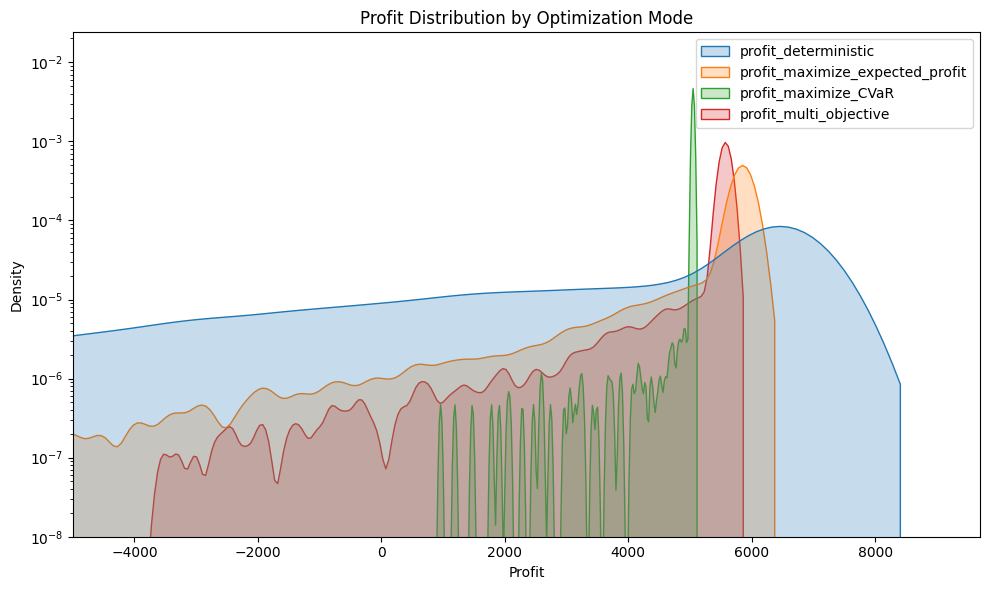

,mode,q1,q2,expected_profit,var_5,cvar_5,mean_profit,std_profit,min_profit,max_profit
0,deterministic,6000.0,10500.0,3769.024445,-4753.541276,-7588.928487,3769.024445,3962.767011,-15516.357256,6525.00
1,maximize_expected_profit,6116.0,8939.0,5550.390786,3841.419554,1551.268673,5550.390786,1085.177083,-6115.557256,5857.35
2,maximize_CVaR,5262.0,7717.0,5042.233443,5051.250000,4871.278796,5042.233443,134.271708,960.242744,5051.25
3,multi_objective,5844.0,8495.0,5460.767822,4999.522015,3418.516894,5460.767822,604.844174,-3533.157256,5575.95


In [3]:
from production_solver import ProductionSolver, OptimizationMode

# Create solver
solver = ProductionSolver(number_scenarios=10000, time_limit=15)

# Solve with different modes
solver.solve(OptimizationMode.DETERMINISTIC)
solver.solve(OptimizationMode.MAXIMIZE_EXPECTED_PROFIT)
solver.solve(OptimizationMode.MAXIMIZE_CVAR)
# excellent CVar would be: solver._solutions['maximize_CVaR']['cvar_5']
# excellent profit would be: solver._solutions['maximize_expected_profit']['expected_profit']
solver.set_multi_objective_params(fair_cvar=3000, excellent_cvar=4000, fair_exp_profit=5400, excellent_exp_profit=5554)
solver.solve(OptimizationMode.MULTI_OBJECTIVE)

# Plot profit distributions
solver.plot_profit_distribution()

# View summary table
solver.get_summary()

### Monte Carlo simulation to replicate the distributions

In [4]:
def simulate_profit(
    solution: list[float],
    n_samples: int = 1000,
    seed: int = 42
) -> np.ndarray:
    """Simulate profit by sampling true demand from distributions.

    Args:
        solution: Production quantities [q1, q2] for products 1 and 2.
        n_samples: Number of Monte Carlo samples.
        seed: Random seed for reproducibility.

    Returns:
        Array of simulated profits.
    """
    np.random.seed(seed)

    q1, q2 = solution

    # Sample demand: demand = base * noise, where noise ~ N(1, 0.1) truncated to [0, 2]
    # Using truncated normal for both products
    noise1 = np.clip(np.random.normal(1, 0.1, n_samples), 0, 2)
    noise2 = np.clip(np.random.normal(1, 0.1, n_samples), 0, 2)

    demand1 = 7000 * noise1
    demand2 = 10500 * noise2

    # Sold = min(produced, demand)
    sold1 = np.minimum(q1, demand1)
    sold2 = np.minimum(q2, demand2)

    # Excess = max(0, produced - sold)
    excess1 = np.maximum(0, q1 - sold1)
    excess2 = np.maximum(0, q2 - sold2)

    # Profit calculation
    profit = 0.3 * sold1 + 0.45 * sold2 - 2.7 * excess1 - 6.0 * excess2

    return profit

deterministic: solution=[6000.0, 10500.0], mean_profit=3800.51
maximize_expected_profit: solution=[6116.0, 8939.0], mean_profit=5547.73
maximize_CVaR: solution=[5262.0, 7717.0], mean_profit=5035.32
multi_objective: solution=[5844.0, 8495.0], mean_profit=5451.99


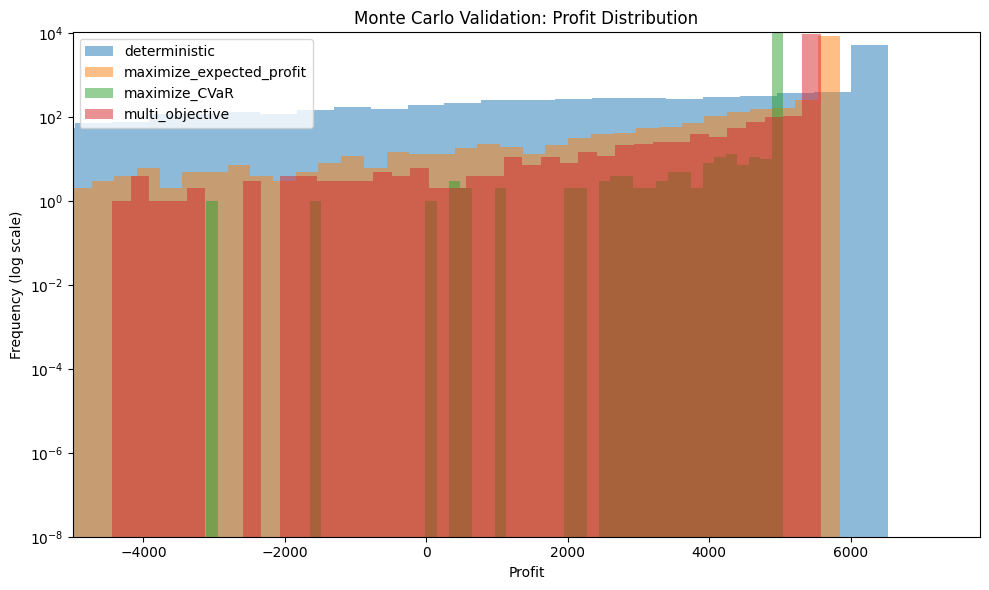

In [5]:
# Get solutions from the solver
solutions_to_validate = {
    'deterministic': solver._solutions['deterministic']['solution'],
    'maximize_expected_profit': solver._solutions['maximize_expected_profit']['solution'],
    'maximize_CVaR': solver._solutions['maximize_CVaR']['solution'],
    'multi_objective': solver._solutions['multi_objective']['solution'],
}

# Simulate profits for each solution
simulated_profits = {}
for mode_name, sol in solutions_to_validate.items():
    simulated_profits[mode_name] = simulate_profit(sol, n_samples=10000, seed=42)
    print(f"{mode_name}: solution={sol}, mean_profit={np.mean(simulated_profits[mode_name]):.2f}")

# Create DataFrame and plot histogram
sim_df = pd.DataFrame(simulated_profits)

plt.figure(figsize=(10, 6))
for col in sim_df.columns:
    plt.hist(sim_df[col], bins=50, alpha=0.5, label=col)
plt.xlim(left=-5000)
plt.ylim(bottom=1e-8)
plt.yscale('log')
plt.xlabel('Profit')
plt.ylabel('Frequency (log scale)')
plt.title('Monte Carlo Validation: Profit Distribution')
plt.legend()
plt.tight_layout()
plt.show()
